dataset loaded successfully
  freelancer_id  year quarter        city  gender   age  age_missing_flag  \
0   PK-FL-00001  2022      Q3  Rawalpindi    Male  21.0                 0   
1   PK-FL-00002  2025      Q4    Peshawar    Male  18.0                 0   
2   PK-FL-00003  2020      Q2   Hyderabad    Male  44.0                 0   
3   PK-FL-00004  2019      Q2    Peshawar    Male  31.0                 0   
4   PK-FL-00005  2021      Q3  Gujranwala  Female  36.0                 0   

                education_level  edu_missing_flag english_proficiency  ...  \
0                    Bachelor's                 1               Basic  ...   
1                    Bachelor's                 0      Conversational  ...   
2                      Master's                 0    Native/Bilingual  ...   
3                    Bachelor's                 0              Fluent  ...   
4  Self-taught/No Formal Degree                 0    Native/Bilingual  ...   

   jobs_completed review_score review_mi

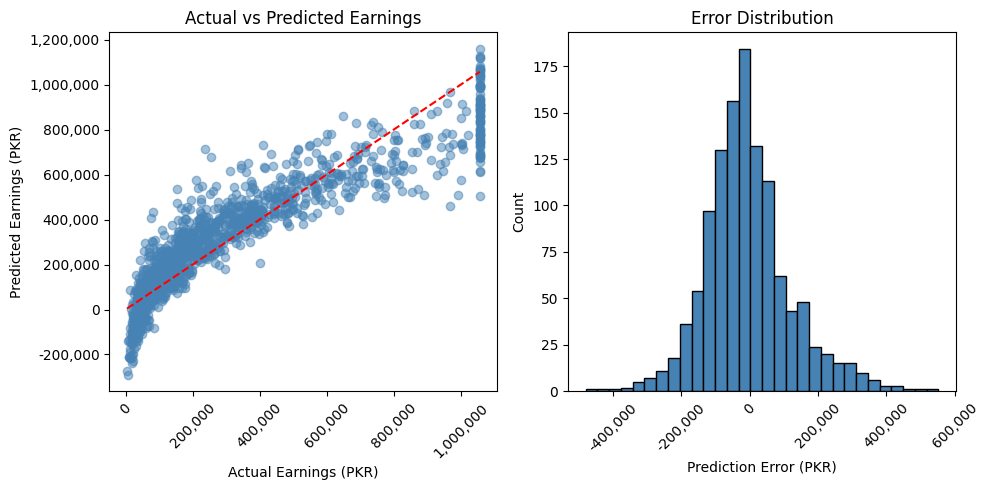

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# loading csv file
df = pd.read_csv("/content/sample_data/pk_freelancing_economy_2015_2025.csv");
# checking dataset loaded or not
if df is not None:
  print("dataset loaded successfully");

# EDA
print(df.head())
print(df.tail())
print(df.shape)
print(df.dtypes)
print(df.describe())
print(df.isnull().sum())
print(df.isnull().sum() / len(df) * 100)
print(df.duplicated().sum())

# Checking Outliers
for col in df.select_dtypes(include=['int64', 'float64']).columns: # select_dtypes → only checks numerical columns (skip object/categorical)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    if len(outliers) > 0:
        print(f"{col} → outliers found: {len(outliers)} rows | lower: {lower:.2f} | upper: {upper:.2f}")
    else:
        print(f"{col} → no outliers")

# checking col names
print(df.columns)

# removing irrelevent columns
cols_to_drop = [
    'freelancer_id', 'age_missing_flag', 'edu_missing_flag',
    'english_missing_flag', 'exp_missing_flag', 'profile_missing_flag',
    'hours_missing_flag', 'review_missing_flag', 'jss_missing_flag',
    'repeat_missing_flag', 'profile_complete_pct',
    'job_success_score_pct', 'repeat_client_rate_pct'
]

df = df.drop(columns=cols_to_drop)

# After removing doing EDA
print(df.shape)
print(df.columns)
print(df.isnull().sum() / len(df) * 100)

# Checking Outliers
for col in df.select_dtypes(include=['int64', 'float64']).columns: # select_dtypes → only checks numerical columns (skip object/categorical)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    if len(outliers) > 0:
        print(f"{col} → outliers found: {len(outliers)} rows | lower: {lower:.2f} | upper: {upper:.2f}")
    else:
        print(f"{col} → no outliers")

# Removing Outliers via CAP Method

# experience_years
df['experience_years'] = df['experience_years'].clip(lower=0, upper=6.75)
# hourly_rate_usd
df['hourly_rate_usd'] = df['hourly_rate_usd'].clip(lower=0, upper=62.85)
# monthly_earnings_usd
df['monthly_earnings_usd'] = df['monthly_earnings_usd'].clip(lower=0, upper=4796.38)
# monthly_earnings_pkr
df['monthly_earnings_pkr'] = df['monthly_earnings_pkr'].clip(lower=0, upper=1056822.38)
# jobs_completed
df['jobs_completed'] = df['jobs_completed'].clip(lower=0, upper=288.50)

# Checking Outliers
for col in df.select_dtypes(include=['int64', 'float64']).columns: # select_dtypes → only checks numerical columns (skip object/categorical)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    if len(outliers) > 0:
        print(f"{col} → outliers found: {len(outliers)} rows | lower: {lower:.2f} | upper: {upper:.2f}")
    else:
        print(f"{col} → no outliers")

# Checking null values
print(df.isnull().sum() / len(df) * 100)
print(df['review_score'].dtype)

# removing null value
df['review_score'] = df['review_score'].fillna(df['review_score'].median())
# checking again for null values
print(df.isnull().sum() / len(df) * 100)

# feature extraction
X = df.drop(['monthly_earnings_pkr', 'monthly_earnings_usd',
             'pkr_usd_rate', 'city', 'primary_skill'], axis=1)
y = df['monthly_earnings_pkr']


for col in X.columns:
    print(col, "→", X[col].dtype, "→ unique:", X[col].nunique(), "→ sample:", X[col].unique()[:4])

col_for_scaling = ['year', 'age', 'account_age_years', 'experience_years',
           'hourly_rate_usd', 'monthly_active_hours',
           'jobs_completed', 'review_score']
col_for_one_hot_encoding = ['quarter', 'platform', 'profile_level',
           'skill_category', 'primary_client_region',
           'payment_method']
col_for_label_encoding = ['gender', 'freelancing_as_primary_income']
# map() for ordered columns
education_map = {
    'Self-taught/No Formal Degree': 0,
    'Matric/O-Levels': 1,
    'Intermediate/A-Levels': 2,
    "Bachelor's": 3,
    "Master's": 4,
    'PhD/MPhil': 5
}

english_map = {
    'Basic': 0,
    'Conversational': 1,
    'Fluent': 2,
    'Native/Bilingual': 3
}

X['education_level'] = X['education_level'].map(education_map)
X['english_proficiency'] = X['english_proficiency'].map(english_map)

for col in col_for_label_encoding:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
for col in col_for_one_hot_encoding:
    X = pd.get_dummies(X, columns=[col], drop_first=True)

scaler = StandardScaler()
X[col_for_scaling] = scaler.fit_transform(X[col_for_scaling])


# check where NaN exists
print(X.isnull().sum())

print(df['education_level'].unique())

print(X.head())
print(X.dtypes)

# train/test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42);

model = LinearRegression();
model.fit(X_train, y_train);    # learn from training data
y_pred = model.predict(X_test); # predict on unseen data

# evaluation metrics

print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: Rs. {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f} PKR")
print(f"MSE: Rs. {mean_squared_error(y_test, y_pred):,.0f} PKR")

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Earnings (PKR)')
plt.ylabel('Predicted Earnings (PKR)')
plt.title('Actual vs Predicted Earnings')
# format axes to show full numbers with commas
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
errors = y_test - y_pred
plt.hist(errors, bins=30, color='steelblue', edgecolor='black')
plt.xlabel('Prediction Error (PKR)')
plt.ylabel('Count')
plt.title('Error Distribution')
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()